In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
plt.style.use('default')
import matplotlib
import pandas as pd
import os
import re
from tqdm import tqdm
from dspeed.processors.trap_filters import trap_norm
from tools import load_waveform_data, compute_pickoff_values_and_plot_random, add_tail_slope_to_dataframe,calculate_tail_slope, query_and_plot_waveform
color_array=np.linspace(0,1,11)
cmap = plt.cm.tab20b

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>")) #makes the notebook wider
plt.style.use('default')
import h5py

detector = 'P00698A' # 'ICPC' 'P42575A' 'UNC_scanner' 'ponama_1' 'V07647A' ,'P00698A'
sim_time=16000
step_time_out = 16
rise = 10000 
flat = 3000
pickoff = 13000
field_dir = '/work/users/k/b/kbhimani/EH-Drift_data/fields/'
wf_directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'


In [2]:
waveforms_df = load_waveform_data(wf_directory)
activeness = compute_pickoff_values_and_plot_random(waveforms_df, rise_samp := math.floor(rise/step_time_out), flat_samp := math.floor(flat/step_time_out), pickoff_samp := math.floor(pickoff/step_time_out), plot_random=False)

100%|██████████| 1/1 [00:01<00:00,  1.46s/it]


Here's how to plot electic field of the detector for one half. We want to use the maps to define valid x and y for the detector. All the points with valid field are valid points. 

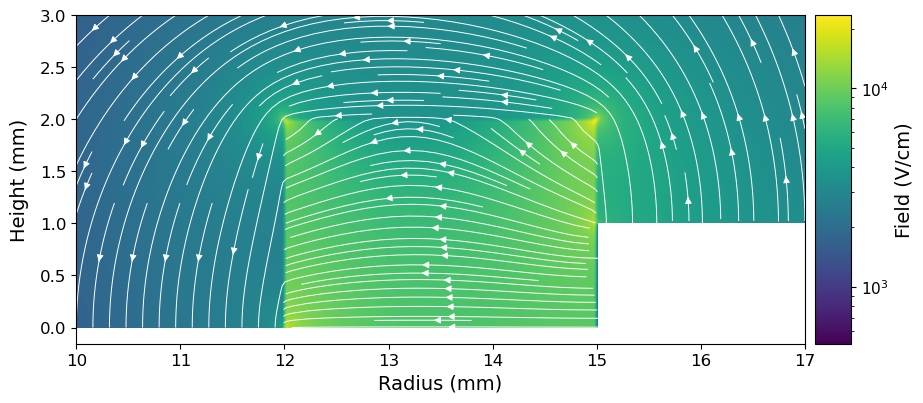

In [3]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
field_dir = '/work/users/k/b/kbhimani/EH-Drift_data/fields/'

detector= 'V07647A' #'ponama_1' #P00698A

sc_plot_1 = -0.3
data = np.loadtxt(field_dir + f'ev_fin_{detector}_grid=0.0200_sc={sc_plot_1:.4f}.dat')

# Extracting unique X, Y, and the Z values (field/potential)
x = np.unique(data[:, 0])  # Unique radial positions
y = np.unique(data[:, 1])  # Unique axial positions
z = data[:, 3]             # Field values # column 3 = field, 2 = potential
E_r = data[:, 4]           # Radial electric field (V/cm)
E_z = data[:, 5]           # Axial electric field (V/cm)

# Reshape Z, E_r, and E_z into grids
zvals = z.reshape(len(x), len(y))
zvals[zvals < 0] = 0       # Set negative potential values to 0
E_r_vals = E_r.reshape(len(x), len(y))
E_z_vals = E_z.reshape(len(x), len(y))

# Define the range for r and z
r_min, r_max = 10, 17
z_min, z_max = 0, 3

# Create masks to select the subregion
mask_x = (x >= r_min) & (x <= r_max)
mask_y = (y >= z_min) & (y <= z_max)

# Apply masks to x, y, and create a new meshgrid
x_sub = x[mask_x]
y_sub = y[mask_y]
X_sub, Y_sub = np.meshgrid(x_sub, y_sub, indexing='xy')

# Slice the corresponding zvals, E_r_vals, and E_z_vals
zvals_sub = zvals[mask_x][:, mask_y]
E_r_vals_sub = E_r_vals[mask_x][:, mask_y]
E_z_vals_sub = E_z_vals[mask_x][:, mask_y]

# Set near-zero values to NaN to remove grainy areas
zvals_sub[zvals_sub <= 1e-10] = np.nan  

# Define plot bounds for the restricted range
bounds = (r_min, r_max, z_min, z_max)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 7))

# Use a custom colormap that handles NaNs properly
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='white')  

# Create a divider for the colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust `size` and `pad` for better spacing

# Plot the potential map with LogNorm and corrected colormap
ip = ax.imshow(zvals_sub.T, norm=colors.LogNorm(),
               extent=bounds, origin="lower", cmap=cmap,
               interpolation='bilinear')

# Add a properly scaled colorbar
cbar = plt.colorbar(ip, cax=cax)
cbar.set_label("Field (V/cm)", size=14)
cbar.ax.tick_params(labelsize=11)  # Adjust font size of colorbar ticks

# Overlay electric field lines
ax.streamplot(X_sub, Y_sub, E_r_vals_sub.T, E_z_vals_sub.T,
              color='white', linewidth=0.7, density=1.5, arrowsize=1)

# Add labels and title
ax.set_xlabel("Radius (mm)", size=14)
ax.set_ylabel("Height (mm)", labelpad=8, size=14)
# ax.set_title(f"Field Magnitude with Electric Field Lines for {detector} sc= {sc_plot_1}e10 e/cm²", size=14)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# Save & Show
plt.savefig(f'figs/elect_field_lines_surface_{detector}_sc_{sc_plot_1}.pdf', dpi=100)
plt.show()


using the randomly sampled points we just create we want to calculate the actiness map of the detector. we want to calculate the efficiency of 0nbb events. on the surface there is a degradation due which can be found in the activeness map. if the point is not in the in the activeness map it's activeness is 1. calculate sum(activeness)/number of points

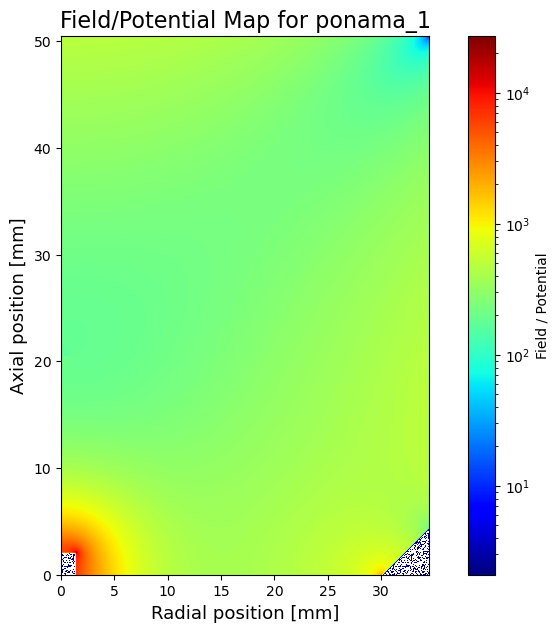

100%|██████████| 1/1 [00:02<00:00,  2.79s/it]


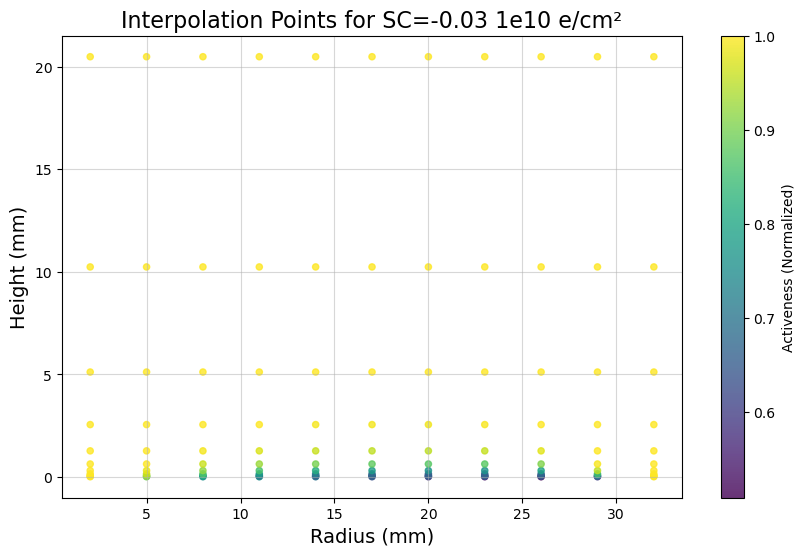

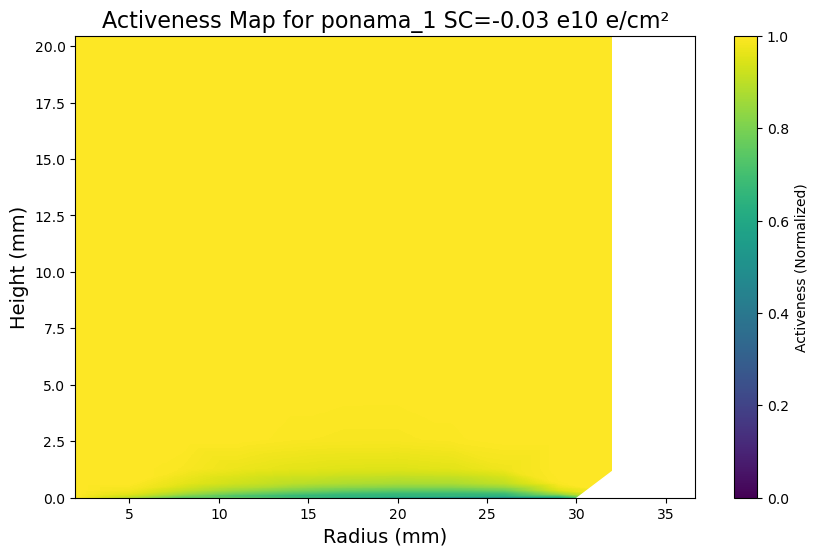

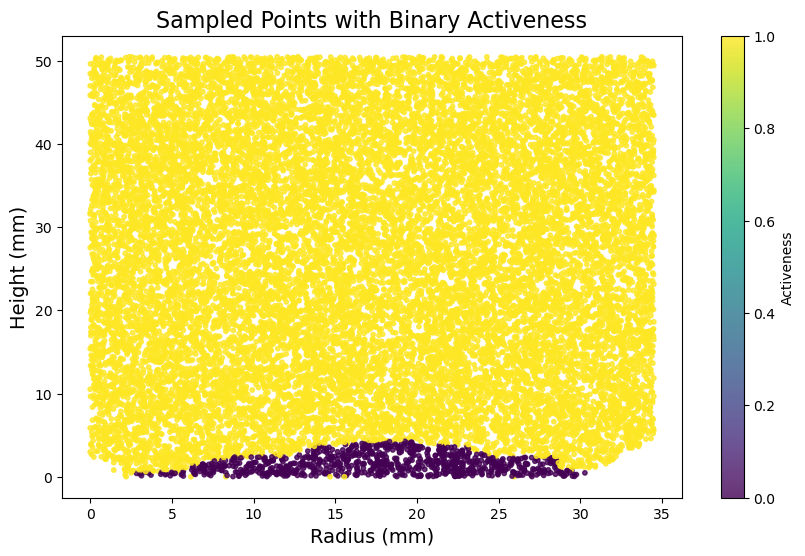

Efficiency of the detector for 0νββ events (r-weighted): 0.9559


In [4]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.path import Path

import matplotlib.colors as colors
from scipy.interpolate import griddata
from tqdm import tqdm
from matplotlib.patches import Polygon

import numpy as np
import pandas as pd
import math
from tools import load_waveform_data, compute_pickoff_values_and_plot_random

# Parameters
detector= 'ponama_1' #P00698A #V07647A ponama_1
energy_peak = 2039  # keV
energy_tolerance = 3  # keV
grid_size = 500
v_min, v_max = 0, 1
shift = 0.03
num_samples = 20000  # Number of valid points to sample
filter_sc = -0.03

field_dir = '/work/users/k/b/kbhimani/EH-Drift_data/fields/'

# Load field data
field_data = np.loadtxt(field_dir + f'ev_fin_{detector}_grid=0.0200_sc=-0.3000.dat')
x = np.unique(field_data[:, 0])  # Radial positions
y = np.unique(field_data[:, 1])  # Axial positions
z = field_data[:, 3]  # Field/potential values

# Reshape Z values into a grid
zvals = z.reshape(len(x), len(y))
zvals[zvals < 0] = 0  # Set invalid fields to 0

# Identify valid points with field > 0
valid_indices = np.where(zvals > 0)
valid_x = x[valid_indices[0]]
valid_y = y[valid_indices[1]]
valid_points = np.column_stack((valid_x, valid_y))

# Exclude points within the ditch (r=12 to r=15 and z=0 to z=2) for detector 'V07647A'
if detector == 'V07647A':
    ditch_mask = ~(
        (valid_points[:, 0] >= 12) & (valid_points[:, 0] <= 15) & 
        (valid_points[:, 1] >= 0) & (valid_points[:, 1] <= 2)
    )
    valid_points = valid_points[ditch_mask]

# Plot the field/potential map
plt.figure(figsize=(10, 7))
plt.imshow(zvals.T, norm=colors.LogNorm(),
           extent=(x.min(), x.max(), y.min(), y.max()),
           origin="lower", cmap='jet')
plt.colorbar(label="Field / Potential")
plt.xlabel("Radial position [mm]", fontsize=13)
plt.ylabel("Axial position [mm]", fontsize=13)
plt.title(f"Field/Potential Map for {detector}", fontsize=16)
plt.show()

# Random sampling of valid points
sampled_indices = np.random.choice(len(valid_points), size=num_samples, replace=False)
sampled_points = valid_points[sampled_indices]

# Load waveforms
wf_directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'
waveforms_df = load_waveform_data(wf_directory)
activeness = compute_pickoff_values_and_plot_random(
    waveforms_df,
    rise_samp := math.floor(rise / step_time_out),
    flat_samp := math.floor(flat / step_time_out),
    pickoff_samp := math.floor(pickoff / step_time_out),
    plot_random=False
)

# Filter waveforms for a specific surface charge
filtered_df = waveforms_df[
    (waveforms_df['det'] == detector) &
    (waveforms_df['sc'] == filter_sc) &
    (waveforms_df['eng'] == 2039) &
    (waveforms_df['sf_drift'] == 0.001)
].copy()

# Add values for max(r) for all unique z-values
unique_z_values = filtered_df['z'].unique()
existing_z_at_max_r = filtered_df.loc[filtered_df['r'] >= max(filtered_df['r']), 'z'].unique()
missing_z_values = np.setdiff1d(unique_z_values, existing_z_at_max_r)

new_rows = pd.DataFrame({
    'r': [max(filtered_df['r'])] * len(missing_z_values),
    'z': missing_z_values,
    'energy_estimate': [1.0] * len(missing_z_values)
})

filtered_df = pd.concat([filtered_df, new_rows], ignore_index=True)

# Adjust activeness
filtered_df.loc[filtered_df['r'] >= max(filtered_df['r']), 'energy_estimate'] = 1.0
filtered_df['energy_estimate'] += shift
filtered_df['energy_estimate'] = filtered_df['energy_estimate'].clip(upper=1.0)

# Define active threshold
active_threshold = (
    np.mean(filtered_df['energy_estimate'][filtered_df['energy_estimate'] > 1 - shift])
    - (energy_tolerance / energy_peak)
)

# Extract r, z, and energy_estimate
r_plot = filtered_df['r'].to_numpy()
z_plot = filtered_df['z'].to_numpy()
energy_estimate_combined = filtered_df['energy_estimate'].to_numpy()

# Plot interpolation grid points
plt.figure(figsize=(10, 6))
plt.scatter(r_plot, z_plot, c=energy_estimate_combined, cmap=cm.viridis, s=20, alpha=0.8)
plt.colorbar(label="Activeness (Normalized)")
plt.xlabel("Radius (mm)", fontsize=14)
plt.ylabel("Height (mm)", fontsize=14)
plt.title(f"Interpolation Points for SC={filter_sc} 1e10 e/cm²", fontsize=16)
plt.grid(alpha=0.5)
plt.show()

# Interpolation grid
r_lin = np.linspace(r_plot.min(), r_plot.max(), grid_size)
z_lin = np.linspace(z_plot.min(), z_plot.max(), grid_size)
r_grid, z_grid = np.meshgrid(r_lin, z_lin)

# Interpolate activeness data
energy_interp = griddata(
    (r_plot, z_plot),
    energy_estimate_combined,
    (r_grid, z_grid),
    method='linear'
)
energy_interp_adjusted = energy_interp[:-1, :-1]
energy_interp_clipped = np.clip(energy_interp_adjusted, v_min, v_max)

# # Plot the interpolated activeness map
# plt.figure(figsize=(10, 6))
# plt.pcolormesh(r_grid[:-1, :-1], z_grid[:-1, :-1], energy_interp_clipped,
#                cmap=cm.viridis, shading='auto', vmin=v_min, vmax=v_max)
# plt.colorbar(label="Activeness (Normalized)")

# plt.xlabel("Radius (mm)", fontsize=14)
# plt.ylabel("Height (mm)", fontsize=14)
# plt.title(f"Activeness Map for SC={filter_sc}", fontsize=16)
# plt.show()

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Overlay the activeness map
plt.figure(figsize=(10, 6))
plt.pcolormesh(r_grid[:-1, :-1], z_grid[:-1, :-1], energy_interp_clipped,
               cmap=cm.viridis, shading='auto', vmin=v_min, vmax=v_max)
plt.colorbar(label="Activeness (Normalized)")

# Define the coordinates of the white triangle
triangle_vertices = [(30, 0), (35, 0), (35, 3)]
triangle = Polygon(triangle_vertices, closed=True, color='white', alpha=1.0)

# Add the triangle to the plot
plt.gca().add_patch(triangle)

# Set axis labels and title
# plt.axhline(0.75)
plt.xlabel("Radius (mm)", fontsize=14)
plt.ylabel("Height (mm)", fontsize=14)
plt.title(f"Activeness Map for {detector} SC={filter_sc} e10 e/cm²", fontsize=16)
plt.show()




# Binary activeness for sampled points
sampled_r = sampled_points[:, 0]
sampled_z = sampled_points[:, 1]
sampled_activeness = griddata(
    (r_grid[:-1, :-1].flatten(), z_grid[:-1, :-1].flatten()),
    energy_interp_clipped.flatten(),
    (sampled_r, sampled_z),
    method='linear',
    fill_value=1.0
)

binary_activeness = np.where(sampled_activeness >= active_threshold, 1.0, 0.0)



# Plot sampled points with binary activeness
plt.figure(figsize=(10, 6))
plt.scatter(sampled_r, sampled_z, c=binary_activeness, cmap=cm.viridis, s=10, alpha=0.8)
plt.colorbar(label="Activeness")

plt.xlabel("Radius (mm)", fontsize=14)
plt.ylabel("Height (mm)", fontsize=14)
plt.title("Sampled Points with Binary Activeness", fontsize=16)
plt.savefig(f'figs/bianry_act_{detector}_{filter_sc}.png')
plt.show()

# Efficiency calculation
efficiency = np.sum(sampled_r * binary_activeness) / np.sum(sampled_r)
print(f"Efficiency of the detector for 0νββ events (r-weighted): {efficiency:.4f}")


In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.interpolate import griddata
from tqdm import tqdm
import numpy as np
import pandas as pd
import math
from tools import load_waveform_data, compute_pickoff_values_and_plot_random

# Parameters
surface_charges = [-0.3, -0.15, -0.03, 0.00, 0.03, 0.15, 0.3]
energy_peak = 2039  # keV
energy_tolerance = 3  # keV
grid_size = 500
v_min, v_max = 0, 1
shift = 0.03
num_samples = 20000  # Number of valid points to sample
detectors = ['V07647A', 'ponama_1', 'P00698A']  # List of detectors to analyze
field_dir = '/work/users/k/b/kbhimani/EH-Drift_data/fields/'

# Store results
efficiency_results = {det: [] for det in detectors}

for detector in tqdm(detectors):
    # Load field data
    field_data = np.loadtxt(field_dir + f'ev_fin_{detector}_grid=0.0200_sc=-0.3000.dat')
    x = np.unique(field_data[:, 0])  # Radial positions
    y = np.unique(field_data[:, 1])  # Axial positions
    z = field_data[:, 3]  # Field/potential values

    # Reshape Z values into a grid
    zvals = z.reshape(len(x), len(y))
    zvals[zvals < 0] = 0  # Set invalid fields to 0

    # Identify valid points with field > 0
    valid_indices = np.where(zvals > 0)
    valid_x = x[valid_indices[0]]
    valid_y = y[valid_indices[1]]
    valid_points = np.column_stack((valid_x, valid_y))

    # Exclude points within the ditch for 'V07647A'
    if detector == 'V07647A':
        ditch_mask = ~(
            (valid_points[:, 0] >= 12) & (valid_points[:, 0] <= 15) &
            (valid_points[:, 1] >= 0) & (valid_points[:, 1] <= 2)
        )
        valid_points = valid_points[ditch_mask]

    # Random sampling of valid points
    sampled_indices = np.random.choice(len(valid_points), size=num_samples, replace=False)
    sampled_points = valid_points[sampled_indices]

    # Load waveforms
    wf_directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'
    waveforms_df = load_waveform_data(wf_directory)
    activeness = compute_pickoff_values_and_plot_random(
        waveforms_df,
        rise_samp := math.floor(rise / step_time_out),
        flat_samp := math.floor(flat / step_time_out),
        pickoff_samp := math.floor(pickoff / step_time_out),
        plot_random=False
    )

    for filter_sc in surface_charges:
        # Filter waveforms for the specific surface charge
        filtered_df = waveforms_df[
            (waveforms_df['det'] == detector) &
            (waveforms_df['sc'] == filter_sc) &
            (waveforms_df['eng'] == 2039) &
            (waveforms_df['sf_drift'] == 0.001)
        ].copy()

        # Add values for max(r) for all unique z-values
        unique_z_values = filtered_df['z'].unique()
        existing_z_at_max_r = filtered_df.loc[filtered_df['r'] >= max(filtered_df['r']), 'z'].unique()
        missing_z_values = np.setdiff1d(unique_z_values, existing_z_at_max_r)

        new_rows = pd.DataFrame({
            'r': [max(filtered_df['r'])] * len(missing_z_values),
            'z': missing_z_values,
            'energy_estimate': [1.0] * len(missing_z_values)
        })

        filtered_df = pd.concat([filtered_df, new_rows], ignore_index=True)

        # Adjust activeness
        filtered_df.loc[filtered_df['r'] >= max(filtered_df['r']), 'energy_estimate'] = 1.0
        filtered_df['energy_estimate'] += shift
        filtered_df['energy_estimate'] = filtered_df['energy_estimate'].clip(upper=1.0)

        # Define active threshold
        active_threshold = (
            np.mean(filtered_df['energy_estimate'][filtered_df['energy_estimate'] > 1 - shift])
            - (energy_tolerance / energy_peak)
        )

        # Extract r, z, and energy_estimate
        r_plot = filtered_df['r'].to_numpy()
        z_plot = filtered_df['z'].to_numpy()
        energy_estimate_combined = filtered_df['energy_estimate'].to_numpy()

        # Interpolation grid
        r_lin = np.linspace(r_plot.min(), r_plot.max(), grid_size)
        z_lin = np.linspace(z_plot.min(), z_plot.max(), grid_size)
        r_grid, z_grid = np.meshgrid(r_lin, z_lin)

        # Interpolate activeness data
        energy_interp = griddata(
            (r_plot, z_plot),
            energy_estimate_combined,
            (r_grid, z_grid),
            method='linear'
        )
        energy_interp_adjusted = energy_interp[:-1, :-1]
        energy_interp_clipped = np.clip(energy_interp_adjusted, v_min, v_max)

        # Binary activeness for sampled points
        sampled_r = sampled_points[:, 0]
        sampled_z = sampled_points[:, 1]
        sampled_activeness = griddata(
            (r_grid[:-1, :-1].flatten(), z_grid[:-1, :-1].flatten()),
            energy_interp_clipped.flatten(),
            (sampled_r, sampled_z),
            method='linear',
            fill_value=1.0
        )

        binary_activeness = np.where(sampled_activeness >= active_threshold, 1.0, 0.0)

        # Efficiency calculation
        efficiency = np.sum(sampled_r * binary_activeness) / np.sum(sampled_r)
        efficiency_results[detector].append(efficiency)
import pickle
# Save surface charges and efficiency results together
results = {"surface_charges": surface_charges, "efficiency_results": efficiency_results}
efficiency_file = "/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/efficiency_results.pkl"

# Save the data using pickle
with open(efficiency_file, "wb") as f:
    pickle.dump(results, f)



100%|██████████| 3/3 [03:10<00:00, 63.56s/it]


In [6]:
results

{'surface_charges': [-0.3, -0.15, -0.03, 0.0, 0.03, 0.15, 0.3],
 'efficiency_results': {'V07647A': [0.9979533280785398,
   0.9979533280785398,
   0.9979533280785398,
   0.9979533280785398,
   0.9979533280785398,
   0.9979533280785398,
   0.9979533280785398],
  'ponama_1': [0.840147481460424,
   0.8796725221593239,
   0.9554750663116398,
   0.990188645623432,
   0.9998130805030985,
   0.9987499540552575,
   0.9973019967701429],
  'P00698A': [0.9530831116047305,
   0.9714463525333034,
   0.9880652971903588,
   0.9994806860403799,
   0.9999131383797799,
   0.9987842964966032,
   0.9972505393831246]}}

{'surface_charges': [-0.3, -0.15, -0.03, 0.0, 0.03, 0.15, 0.3], 'efficiency_results': {'V07647A': [0.9979533280785398, 0.9979533280785398, 0.9979533280785398, 0.9979533280785398, 0.9979533280785398, 0.9979533280785398, 0.9979533280785398], 'ponama_1': [0.840147481460424, 0.8796725221593239, 0.9554750663116398, 0.990188645623432, 0.9998130805030985, 0.9987499540552575, 0.9973019967701429], 'P00698A': [0.9530831116047305, 0.9714463525333034, 0.9880652971903588, 0.9994806860403799, 0.9999131383797799, 0.9987842964966032, 0.9972505393831246]}}


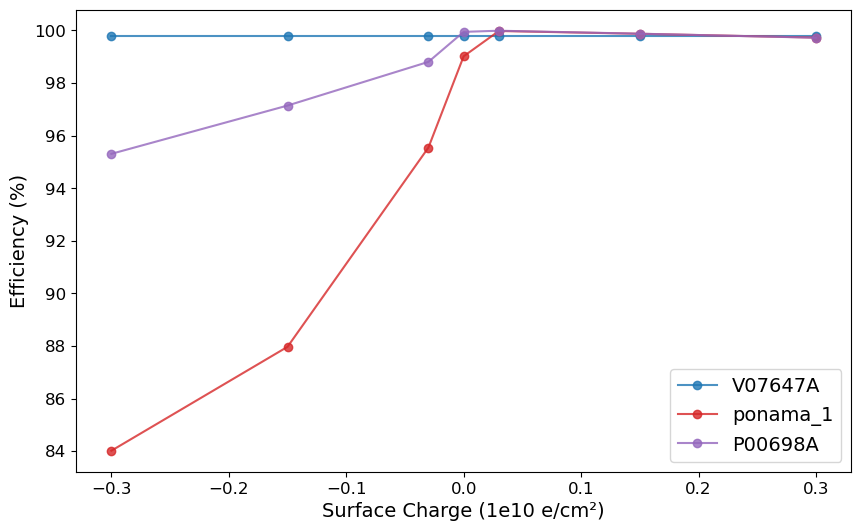

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

efficiency_file = "/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/efficiency_results.pkl"

# Load the saved results
with open(efficiency_file, "rb") as f:
    loaded_results = pickle.load(f)
print(loaded_results)
# Access surface charges and efficiency results
loaded_surface_charges = loaded_results["surface_charges"]
loaded_efficiency_results = loaded_results["efficiency_results"]

# Define colors for the detectors
colors = ['tab:blue', 'tab:red', 'tab:purple']
detector_labels = ['V07647A', 'ponama_1', 'P00698A']  # Custom labels

# Plot Efficiency vs. Surface Charge
plt.figure(figsize=(10, 6))
for i, (detector, efficiencies) in enumerate(loaded_efficiency_results.items()):
    plt.plot(loaded_surface_charges, np.array(efficiencies) * 100, 'o-', color=colors[i], alpha=0.8, label=detector_labels[i])

# Set labels, title, and legend
plt.xlabel("Surface Charge (1e10 e/cm²)", fontsize=14)
plt.ylabel("Efficiency (%)", fontsize=14)
# plt.title("Efficiency vs. Surface Charge for Different Detectors", fontsize=16)
plt.legend(fontsize=14, loc='best')  # Place legend in the best position
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels
# Save and show the plot
plt.savefig("figs/efficiency_0nbb.pdf")
plt.show()
